# 09 · 批量结果与独立复核

核对全部回合的状态分母，比较任务与贡献的六级候选分布，再查看同一回合的双维配对。
本页使用 t3 公开聚合表；[02](02_标注与互评.ipynb) 展示固定随机子集的同题流程变化。

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import (
    configure_style, save_figure, export_table, research_inputs,
    final_archive_summary, load_frozen_batch, load_turn_snapshot, load_turn_plan, load_full_turn_materials,
    turn_manifest_summary, pending_results, offline_monthly, COLORS,
)
configure_style()
LIVE_API = False

In [2]:
PUBLIC_DIR = ROOT / "results" / "final-analysis"
public_summary = json.loads((PUBLIC_DIR / "summary.json").read_text(encoding="utf-8"))
public_counts = public_summary["denominators"]
public_source = public_summary["source"]
public_descriptive = pd.read_csv(PUBLIC_DIR / "descriptive.csv")

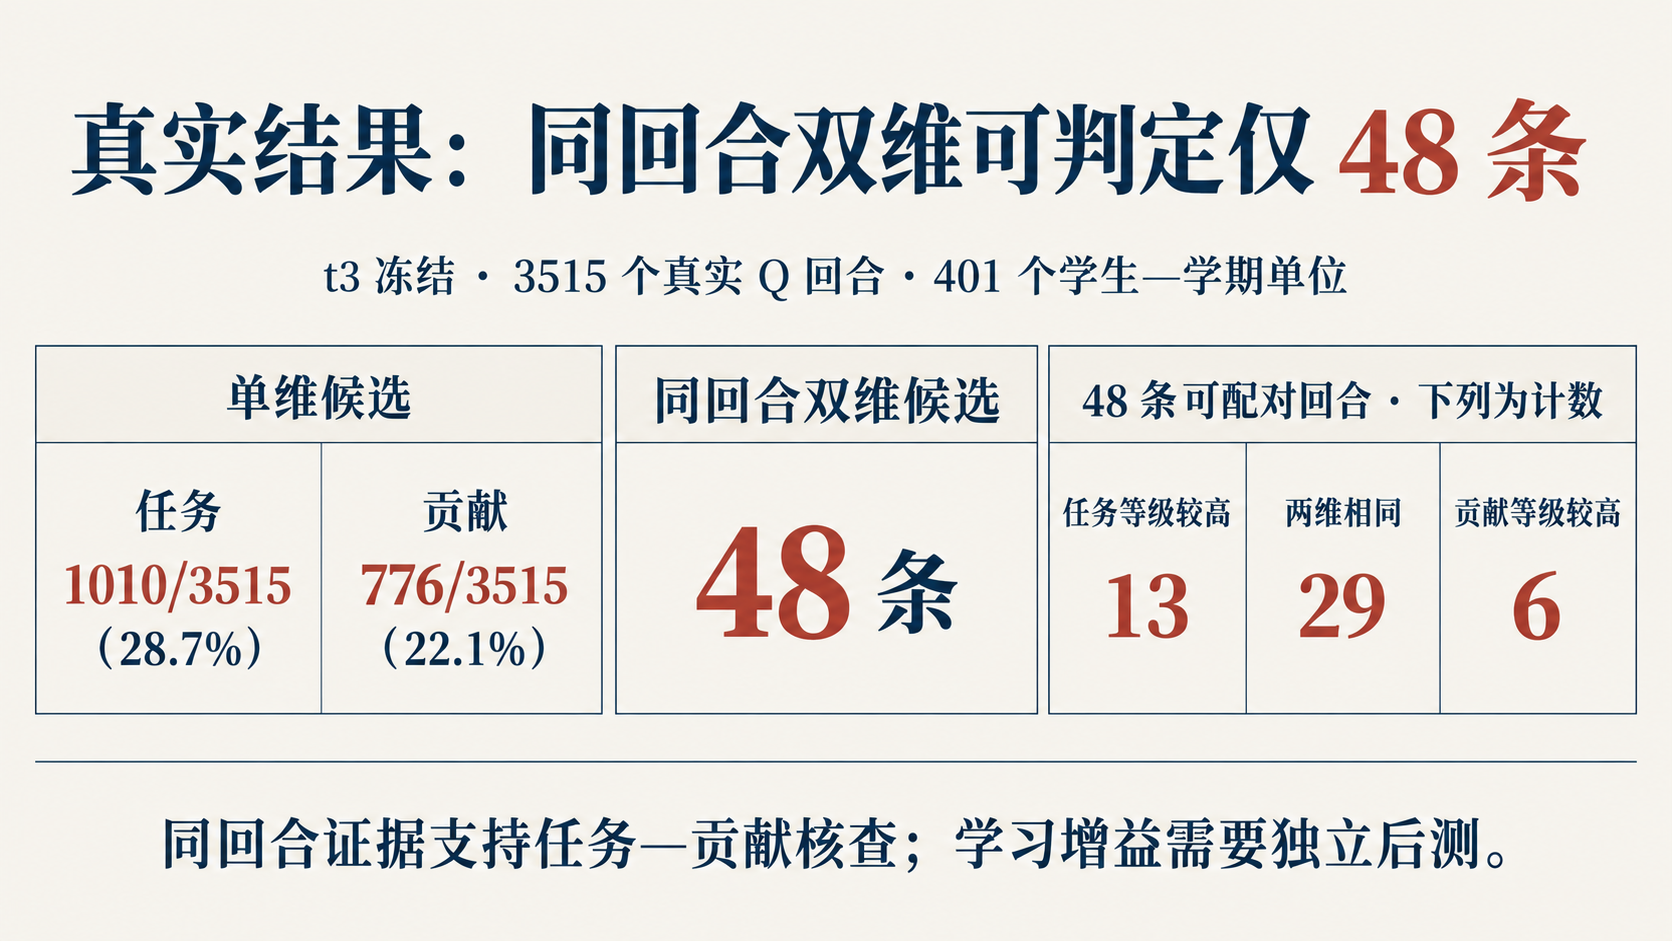

路演05｜3,515个真实回合的双维候选；配对比较使用同回合共同候选。

In [3]:
from IPython.display import Image, Markdown, display
reference_path = ROOT / 'slides/roadshow/images/05.png'
if reference_path.is_file():
    display(Image(filename=str(reference_path), width=960))
    display(Markdown('路演05｜3,515个真实回合的双维候选；配对比较使用同回合共同候选。'))
else:
    display(Markdown('配图未附于本地副本：`' + reference_path.name + '`。可继续执行下方计算。'))

## 阅读口径

- **边际分布**：任务与贡献分别使用自己的候选回合分母。
- **同回合比较**：只使用两维均有候选的共同子集。
- **复核选择**：固定随机子集与高风险子集分开报告。

候选、弃权、分歧、不确定和技术失败各自保留数量。模型一致性描述输出关系；准确性仍需独立参考标签。

In [4]:
final_status = public_descriptive.loc[public_descriptive.term.eq("all"),
    ["dimension", "turns", "agreed", "abstained", "disagreement", "uncertain", "technical_failure"]].copy()
status_columns = ["agreed", "abstained", "disagreement", "uncertain", "technical_failure"]
assert final_status[status_columns].sum(axis=1).eq(final_status.turns).all()
final_status["dimension"] = final_status.dimension.map({"task": "任务", "contribution": "贡献"})
display(final_status.rename(columns={"dimension": "维度", "turns": "全部回合", "agreed": "候选",
    "abstained": "共同弃权", "disagreement": "分歧", "uncertain": "不确定", "technical_failure": "技术失败"}))
export_table(final_status, "public-final-status")

,维度,全部回合,候选,共同弃权,分歧,不确定,技术失败
0,任务,3515,1010,1812,604,76,13
1,贡献,3515,776,2457,268,0,14


## 真实观察：六级分布与同回合双维比较
任务与贡献分别有 1,010 和 776 条候选，占全部 3,515 回合的不同子集。
边际分布用于描述各自候选；两维比较使用同一回合均有候选的 48 条记录。
来源：`descriptive.csv`、`level-distribution.csv`、`joint-levels.csv` 与 `summary.json`，均位于 `results/final-analysis/`。

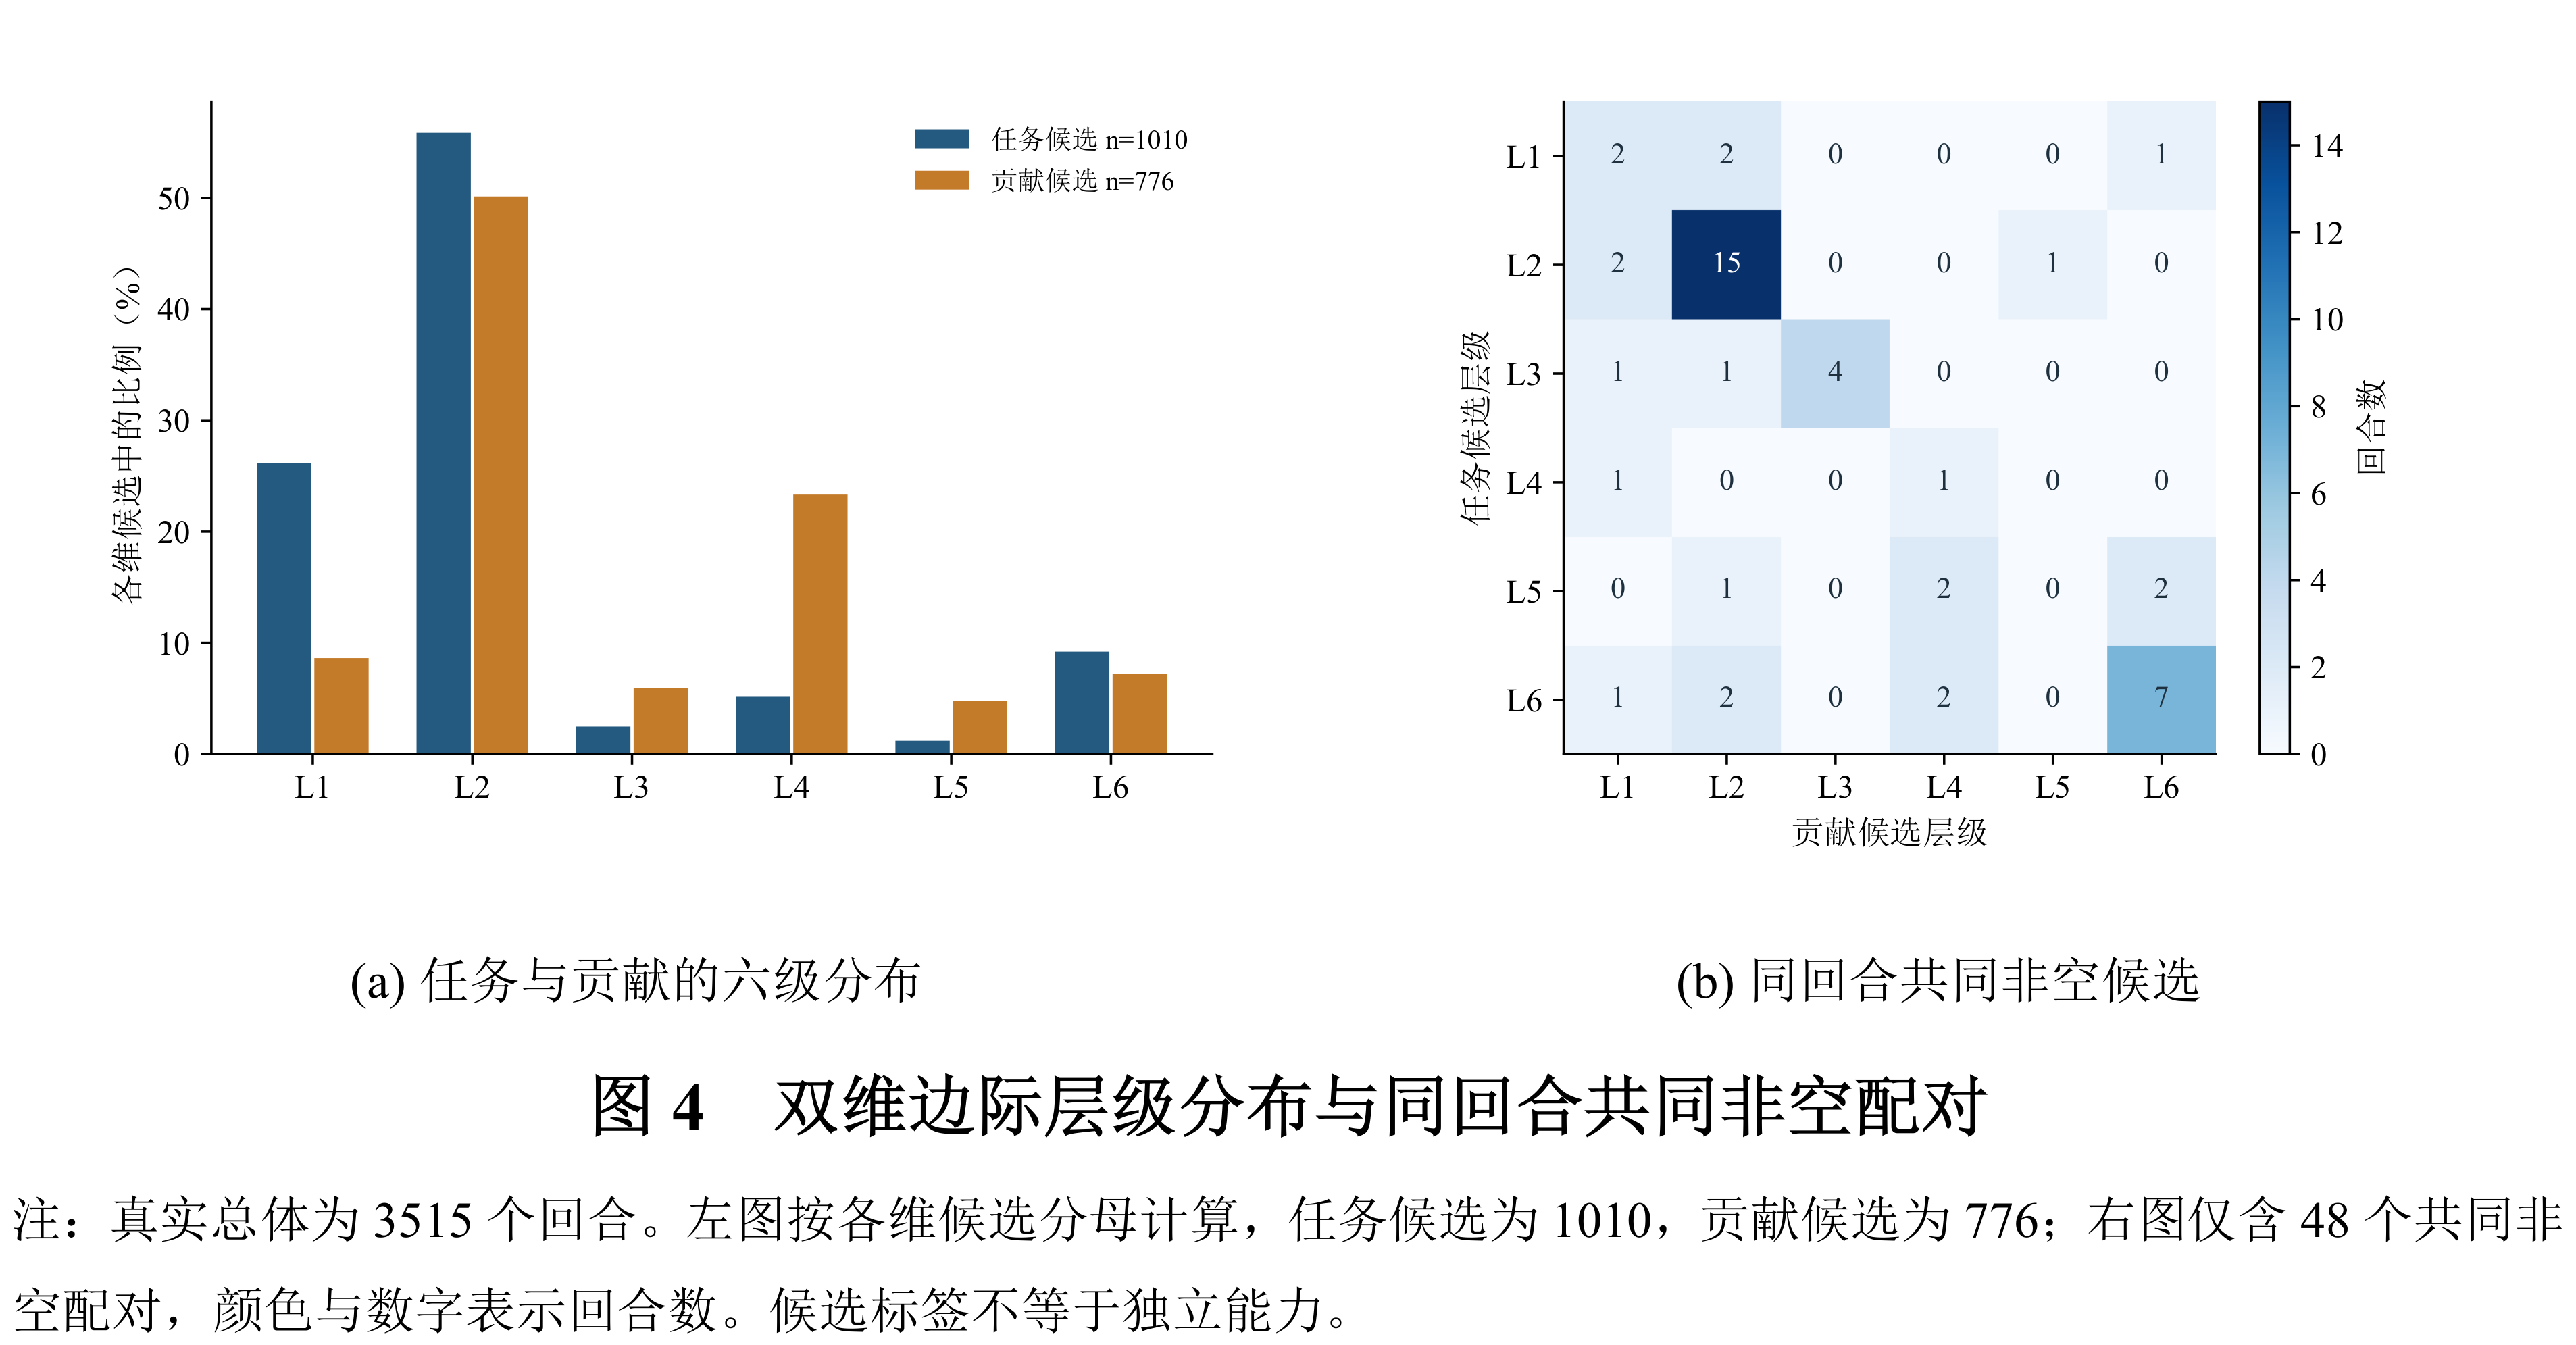

论文图1｜六级边际分布与同回合配对；下面保留汇总表和绘图计算。

In [5]:
from IPython.display import Image, Markdown, display
reference_path = ROOT / 'results/final-analysis/fig01_dimensions.png'
if reference_path.is_file():
    display(Image(filename=str(reference_path), width=960))
    display(Markdown('论文图1｜六级边际分布与同回合配对；下面保留汇总表和绘图计算。'))
else:
    display(Markdown('配图未附于本地副本：`' + reference_path.name + '`。可继续执行下方计算。'))

In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("未找到公开汇总 `results/final-analysis/summary.json`；合成计算可独立运行。"))
else:
    display(pd.DataFrame([{
        "汇总版本": final_summary["source"]["revision"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,汇总版本,真实回合,学生—学期
0,t3,3515,401


,term,dimension,turns,students,candidate_turns,candidate_students,students_without_candidates,candidate_coverage,turn_weighted_abl_raw,equal_student_abl_raw,turn_weighted_hot,equal_student_hot
0,all,task,3515,401,1010,356,45,0.2873,2.2703,2.2868,0.1554,0.1496
1,all,contribution,3515,401,776,244,157,0.2208,2.8711,2.7446,0.3531,0.3170
2,25f,task,2509,295,661,257,38,0.2635,2.5537,2.5566,0.1952,0.1858
3,25f,contribution,2509,295,621,190,105,0.2475,2.9533,2.8187,0.3784,0.3429
4,26s,task,1006,106,349,99,7,0.3469,1.7335,1.5864,0.0802,0.0556
5,26s,contribution,1006,106,155,54,52,0.1541,2.5419,2.4840,0.2516,0.2257


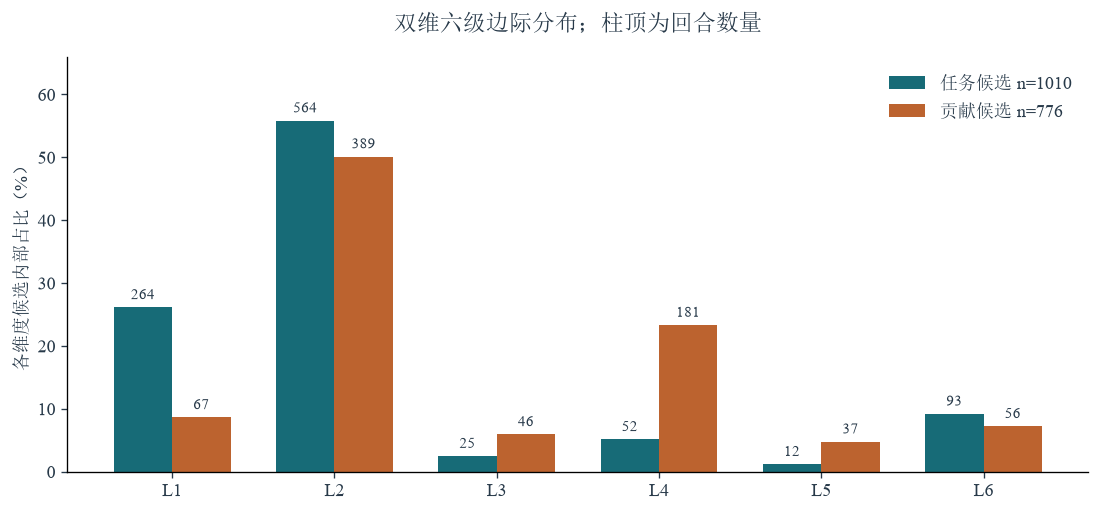

In [7]:
if final_summary is not None:
    descriptive = final_csv("descriptive.csv")
    level_distribution = final_csv("level-distribution.csv")
    display(descriptive[["term", "dimension", "turns", "students", "candidate_turns", "candidate_students", "students_without_candidates", "candidate_coverage", "turn_weighted_abl_raw", "equal_student_abl_raw", "turn_weighted_hot", "equal_student_hot"]].round(4))
    levels_all = level_distribution.loc[level_distribution.term.eq("all")]
    fig, ax = plt.subplots(figsize=(9.3, 4.4))
    for shift, dimension, label, color in [(-.18, "task", "任务候选", "#176B77"), (.18, "contribution", "贡献候选", "#BC632F")]:
        group = levels_all.loc[levels_all.dimension.eq(dimension)].sort_values("level")
        assert group["count"].sum() == group.candidate_denominator.iloc[0]
        bars = ax.bar(group.level+shift, 100*group.candidate_share, width=.36, color=color, label=f"{label} n={int(group.candidate_denominator.iloc[0])}")
        ax.bar_label(bars, labels=[str(int(n)) for n in group["count"]], padding=3, fontsize=9)
    ax.set_xticks(range(1, 7), [f"L{x}" for x in range(1, 7)])
    ax.set(ylim=(0, levels_all.candidate_share.max()*118), ylabel="各维度候选内部占比（%）", title="双维六级边际分布；柱顶为回合数量")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "final-dimension-level-distribution", "各维度分别以自身候选为分母；两个候选集合并非同一批回合。", kind="real", sources=["results/final-analysis/level-distribution.csv", "results/final-analysis/descriptive.csv", "results/final-analysis/summary.json"], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()

按回合加权回答“候选回合的平均标签”；按有候选的学生—学期等权回答“这些学生—学期的平均标签”。
无候选的学生—学期另列，两个加权结果都不能外推为全部学生能力。

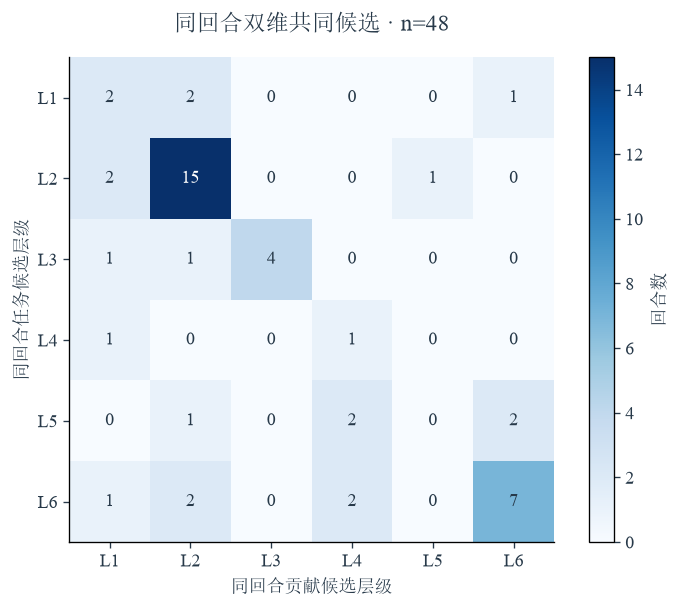

,共同候选,任务较高,相同,贡献较高,任务高阶且贡献非高阶
0,48,13,29,6,5


In [8]:
if final_summary is not None:
    joint_levels = final_csv("joint-levels.csv")
    joint_all = joint_levels.loc[joint_levels.term.eq("all")]
    joint_matrix = joint_all.pivot(index="task_level", columns="contribution_level", values="count").reindex(index=range(1, 7), columns=range(1, 7)).fillna(0).astype(int)
    assert joint_matrix.to_numpy().sum() == final_summary["joint"]["paired_denominator"] == 48
    fig, ax = plt.subplots(figsize=(6.6, 5.2))
    im = ax.imshow(joint_matrix.to_numpy(), cmap="Blues", vmin=0, aspect="equal")
    for y in range(6):
        for x in range(6):
            value = joint_matrix.iloc[y, x]
            ax.text(x, y, str(value), ha="center", va="center", color="white" if value > joint_matrix.to_numpy().max()*.55 else "#273949")
    ax.set_xticks(range(6), [f"L{x}" for x in range(1, 7)])
    ax.set_yticks(range(6), [f"L{x}" for x in range(1, 7)])
    ax.set(xlabel="同回合贡献候选层级", ylabel="同回合任务候选层级", title="同回合双维共同候选 · n=48")
    fig.colorbar(im, ax=ax, label="回合数")
    fig.tight_layout()
    save_figure(fig, "final-joint-candidate-levels", "48条同回合双维非空候选；任务较高13条、相同29条、贡献较高6条。", kind="real", sources=["results/final-analysis/joint-levels.csv", "results/final-analysis/summary.json"], notebook="09_Agent批量结果与互评.ipynb")
    plt.show()
    joint = final_summary["joint"]
    display(pd.DataFrame([{"共同候选": joint["paired_denominator"], "任务较高": joint["task_above_contribution"], "相同": joint["equal"], "贡献较高": joint["task_below_contribution"], "任务高阶且贡献非高阶": joint["task_hot_contribution_not_hot"]}]))

同回合比较得到任务较高 13 条、相同 29 条、贡献较高 6 条，共 48 条。
共同候选仅占全部回合的一小部分；双维边际均值之差不等于这 48 条同回合差值，也不能用来判断全部学生的任务与贡献差距。

**下一步：** [03 · 人工复评与校准条件](03_人审与校准.ipynb)